# results/best vs results/deployment_for_permutations

Compares the 7 curated embeddings' classifier outputs in `results/best` (fit once per embedding, 2024-12) against `results/deployment_for_permutations` (same embeddings/hyperparameters, retrained per 2026-07).

In [1]:
import re
import pickle
import warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)  # sklearn InconsistentVersionWarning on unpickle

REPO_ROOT = Path("/projects/kmanpearl@xsede.org/multiomics-embedding")
BEST_DIR = REPO_ROOT / "results" / "best"
DEPLOY_DIR = REPO_ROOT / "results" / "deployment_for_permutations"

TAGS = ["21tdsqsa", "7o4yga2v", "8lofhbbf", "ai9n4jxs", "q2gzu1o3", "qb4y98x0", "wcksnlsg"]
TASKS = {"time": "Timepoint Classification", "diet": "Diet Classification"}

# colorblind-safe (Okabe-Ito)
COLOR_BEST = "#0072B2"
COLOR_DEPLOY = "#E69F00"


## Parsing helpers

In [2]:
def parse_scores(block: str) -> dict:
    scores = {}
    for metric in ["f1", "balanced_accuracy", "accuracy"]:
        m = re.search(metric + r" validation scores.*?median score: ([\d.]+)", block, re.S)
        if m:
            scores[metric] = float(m.group(1))
    return scores


def parse_hyperparams(block: str) -> dict:
    out = {}
    for key, pattern in [
        ("C", r"best C: ([\d.]+)"),
        ("penalty", r"best penalty: (\w+)"),
        ("solver", r"best solver: (\w+)"),
        ("l1_ratio", r"best l1_ratio: ([\d.]+)"),
    ]:
        m = re.search(pattern, block)
        if m:
            out[key] = float(m.group(1)) if key in ("C", "l1_ratio") else m.group(1)
    return out


def best_task_block(tag: str, task: str) -> str:
    text = (BEST_DIR / f"{tag}_logging.txt").read_text()
    sections = re.split(r"={2,}\s*(Timepoint Classification|Diet Classification)\s*={2,}", text)
    blocks = dict(zip(sections[1::2], sections[2::2]))
    return blocks[TASKS[task]]


def deploy_task_block(tag: str, task: str) -> str:
    return (DEPLOY_DIR / tag / f"{task}_logging.txt").read_text()


## Validation scores: best vs deployment

In [3]:
rows = []
for tag in TAGS:
    for task in TASKS:
        best_scores = parse_scores(best_task_block(tag, task))
        deploy_scores = parse_scores(deploy_task_block(tag, task))
        for metric in ["f1", "balanced_accuracy", "accuracy"]:
            b, d = best_scores[metric], deploy_scores[metric]
            rows.append({"tag": tag, "task": task, "metric": metric,
                         "best": b, "deployment": d, "diff": d - b})

scores_df = pd.DataFrame(rows)
scores_df


,tag,task,metric,best,deployment,diff
0,21tdsqsa,time,f1,0.869565,0.869565,-1.110223e-16
1,21tdsqsa,time,balanced_accuracy,0.854545,0.854545,0.000000e+00
2,21tdsqsa,time,accuracy,0.854545,0.854545,0.000000e+00
3,21tdsqsa,diet,f1,0.800000,0.800000,0.000000e+00
4,21tdsqsa,diet,balanced_accuracy,0.833333,0.833333,0.000000e+00
5,21tdsqsa,diet,accuracy,0.833333,0.833333,0.000000e+00
6,7o4yga2v,time,f1,0.909091,0.909091,0.000000e+00
7,7o4yga2v,time,balanced_accuracy,0.904545,0.904545,0.000000e+00
8,7o4yga2v,time,accuracy,0.904545,0.904545,0.000000e+00
9,7o4yga2v,diet,f1,0.888889,0.888889,-1.110223e-16


In [4]:
pivot = scores_df.pivot_table(index=["tag", "task"], columns="metric", values="diff")
pivot.style.background_gradient(cmap="RdBu_r", vmin=-0.05, vmax=0.05)


## Selected hyperparameters: best vs deployment

In [5]:
hp_rows = []
for tag in TAGS:
    for task in TASKS:
        for source, block in [("best", best_task_block(tag, task)), ("deployment", deploy_task_block(tag, task))]:
            hp = parse_hyperparams(block)
            hp_rows.append({"tag": tag, "task": task, "source": source, **hp})

hp_df = pd.DataFrame(hp_rows)
hp_df


,tag,task,source,C,penalty,solver,l1_ratio
0,21tdsqsa,time,best,351.081491,l2,lbfgs,NaN
1,21tdsqsa,time,deployment,351.081491,l2,lbfgs,NaN
2,21tdsqsa,diet,best,48.989048,elasticnet,saga,0.954787
3,21tdsqsa,diet,deployment,48.989048,elasticnet,saga,0.954787
4,7o4yga2v,time,best,483.308595,l1,liblinear,NaN
5,7o4yga2v,time,deployment,483.308595,l1,liblinear,NaN
6,7o4yga2v,diet,best,3.804434,l1,liblinear,NaN
7,7o4yga2v,diet,deployment,3.804434,l1,liblinear,NaN
8,8lofhbbf,time,best,12.003579,l2,lbfgs,NaN
9,8lofhbbf,time,deployment,12.003579,l2,lbfgs,NaN


## Solver convergence (`n_iter_` vs `max_iter` on the saved fitted model)

In [6]:
conv_rows = []
for tag in TAGS:
    for task in TASKS:
        for source, path in [("best", BEST_DIR / f"{tag}_{task}_model.pkl"),
                              ("deployment", DEPLOY_DIR / tag / f"{task}_model.pkl")]:
            with open(path, "rb") as f:
                model = pickle.load(f)
            n_iter = int(model.n_iter_[0])
            max_iter = model.max_iter
            conv_rows.append({
                "tag": tag, "task": task, "source": source,
                "solver": model.solver, "n_iter_": n_iter, "max_iter": max_iter,
                "converged": n_iter < max_iter,
            })

conv_df = pd.DataFrame(conv_rows)
conv_df


,tag,task,source,solver,n_iter_,max_iter,converged
0,21tdsqsa,time,best,lbfgs,32,100,True
1,21tdsqsa,time,deployment,lbfgs,17,500,True
2,21tdsqsa,diet,best,saga,100,100,False
3,21tdsqsa,diet,deployment,saga,500,500,False
4,7o4yga2v,time,best,liblinear,13,100,True
5,7o4yga2v,time,deployment,liblinear,13,500,True
6,7o4yga2v,diet,best,liblinear,15,100,True
7,7o4yga2v,diet,deployment,liblinear,15,500,True
8,8lofhbbf,time,best,lbfgs,32,100,True
9,8lofhbbf,time,deployment,lbfgs,13,500,True


## Agreement plot: deployment score vs best score

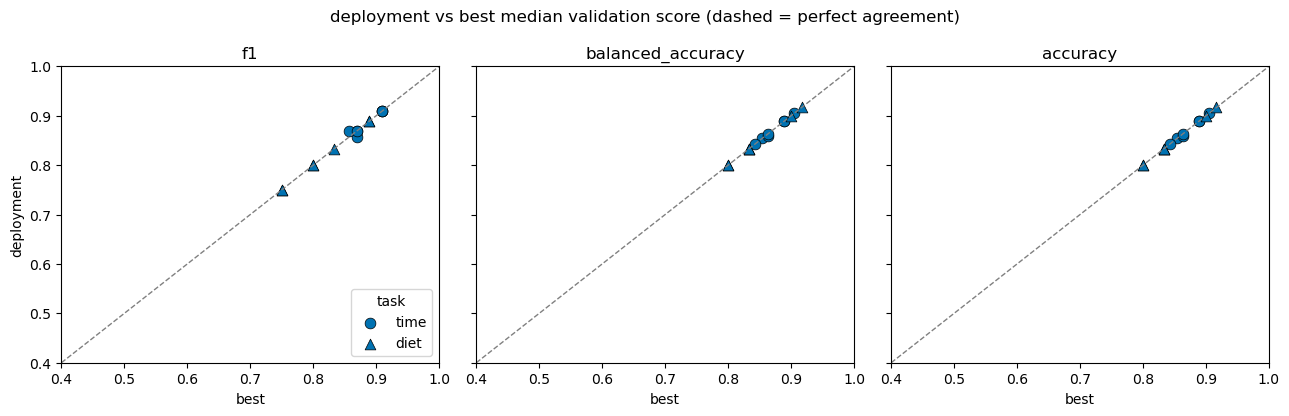

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
markers = {"time": "o", "diet": "^"}
for ax, metric in zip(axes, ["f1", "balanced_accuracy", "accuracy"]):
    sub = scores_df[scores_df["metric"] == metric]
    for task, marker in markers.items():
        s = sub[sub["task"] == task]
        ax.scatter(s["best"], s["deployment"], marker=marker, s=60,
                   color=COLOR_BEST, edgecolor="black", linewidth=0.5, label=task)
    ax.plot([0.4, 1.0], [0.4, 1.0], color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(0.4, 1.0)
    ax.set_ylim(0.4, 1.0)
    ax.set_xlabel("best")
    ax.set_title(metric)
axes[0].set_ylabel("deployment")
axes[0].legend(title="task", loc="lower right")
fig.suptitle("deployment vs best median validation score (dashed = perfect agreement)")
fig.tight_layout()
plt.show()


## Feature-level agreement: majority/unanimous vote, best vs deployment

For each feature (microbiome/metabolites) and direction, counts how many of the 7 `results/best` models vs. how many of the 7 `results/deployment_for_permutations` models call `probability > 0.5`, then compares the majority (>=4/7) and unanimous (7/7) calls between the two sources - do independently-refit models agree on which features they'd flag, not just on aggregate validation scores?

In [8]:
from matplotlib.colors import LogNorm

OMICS_NODE_FILES = {"microbiome": "microbes.txt", "metabolites": "metabolites.txt"}
OMICS_IDS = {}
for omics, fname in OMICS_NODE_FILES.items():
    with open(REPO_ROOT / "data" / "nodes" / fname) as f:
        OMICS_IDS[omics] = {line.strip() for line in f if line.strip()}

GROUP_TO_COLUMN = {
    "time": {"5-month-old": "baseline", "12-month-old": "endpoint"},
    "diet": {"Dairy": "dairy", "Meat": "meat"},
}
SIG_LABELS = ["Associated", "Not Associated"]


def best_paths(task: str) -> list:
    return [BEST_DIR / f"{tag}_{task}_feature_predictions.tsv" for tag in TAGS]


def deploy_paths(task: str) -> list:
    return [DEPLOY_DIR / tag / f"{task}_feature_predictions.tsv" for tag in TAGS]


def hit_ids(paths: list, column: str, omics: str, min_hits: int) -> set:
    probs = pd.concat([pd.read_csv(p, sep="\t", index_col=0)[column] for p in paths], axis=1)
    probs = probs.loc[probs.index.intersection(OMICS_IDS[omics])]
    hits = (probs > 0.5).sum(axis=1) >= min_hits
    return set(probs.index[hits])


def confusion_counts(row_ids: set, col_ids: set, universe: set):
    tp = len(row_ids & col_ids)
    fn = len(row_ids - col_ids)
    fp = len(col_ids - row_ids)
    tn = len(universe) - tp - fn - fp
    return tp, fn, fp, tn


def plot_best_vs_deploy(task: str, min_hits: int, vote_name: str):
    omics_names = list(OMICS_IDS)
    directions = list(GROUP_TO_COLUMN[task])
    fig, axes = plt.subplots(
        len(directions), len(omics_names), figsize=(5.2 * len(omics_names), 5.0 * len(directions)),
        squeeze=False, layout="constrained",
    )
    for i, direction in enumerate(directions):
        column = GROUP_TO_COLUMN[task][direction]
        for j, omics in enumerate(omics_names):
            best_ids = hit_ids(best_paths(task), column, omics, min_hits)
            deploy_ids = hit_ids(deploy_paths(task), column, omics, min_hits)
            universe = OMICS_IDS[omics]
            tp, fn, fp, tn = confusion_counts(best_ids, deploy_ids, universe)
            mat = [[tp, fn], [fp, tn]]
            ax = axes[i][j]
            norm = LogNorm(vmin=1, vmax=max(tp, fn, fp, tn, 1))
            ax.imshow(mat, cmap="Blues", norm=norm)
            for r in range(2):
                for c in range(2):
                    val = mat[r][c]
                    color = "white" if norm(val) > 0.6 else "black"
                    ax.text(c, r, f"{val:,}", ha="center", va="center", color=color, fontsize=15)
            ax.set_xticks([0, 1], labels=SIG_LABELS)
            ax.set_yticks([0, 1], labels=SIG_LABELS)
            ax.set_xlabel("deployment")
            ax.set_ylabel("best")
            ax.set_title(f"{omics} - {direction}")
    fig.suptitle(
        f"{vote_name} agreement: results/best vs. deployment ({task})\n"
        f"(significant: >={min_hits}/{len(TAGS)} embeddings with prob>0.5)"
    )
    plt.show()

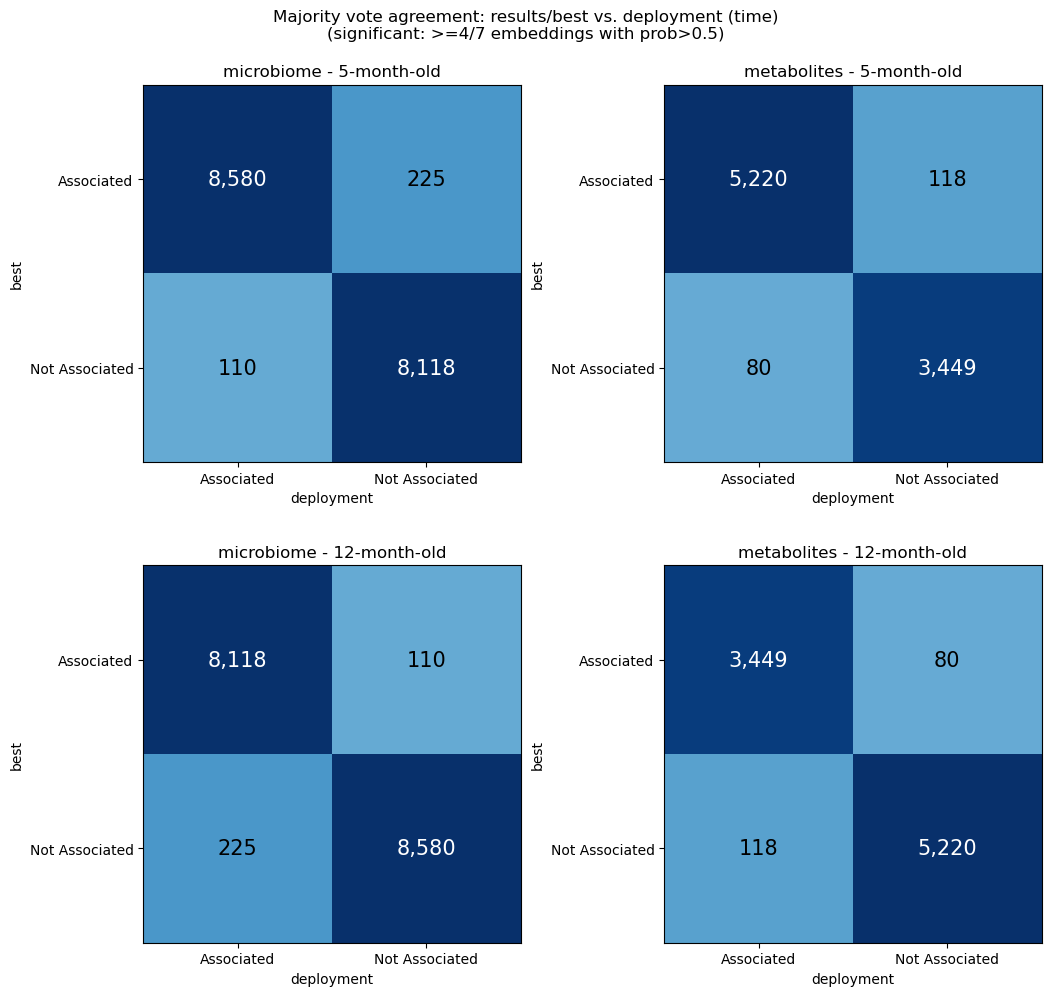

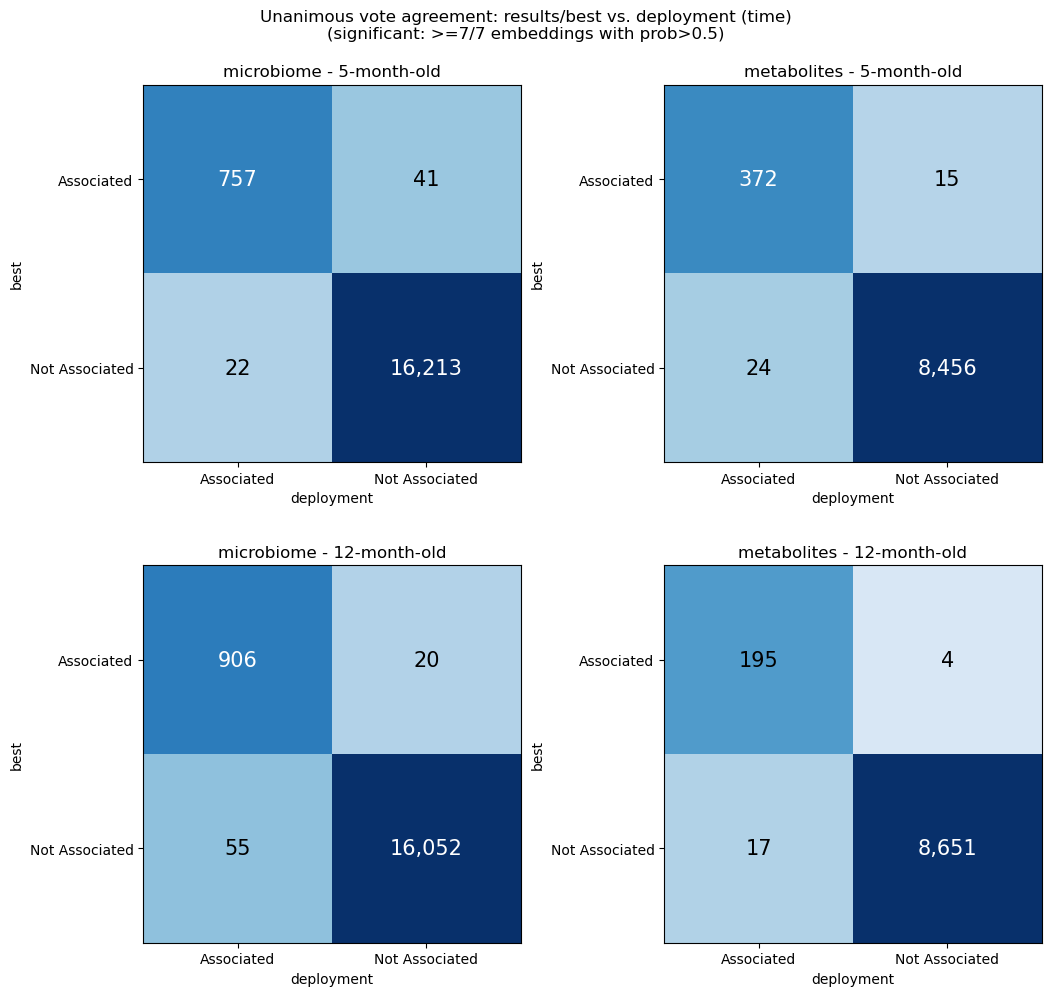

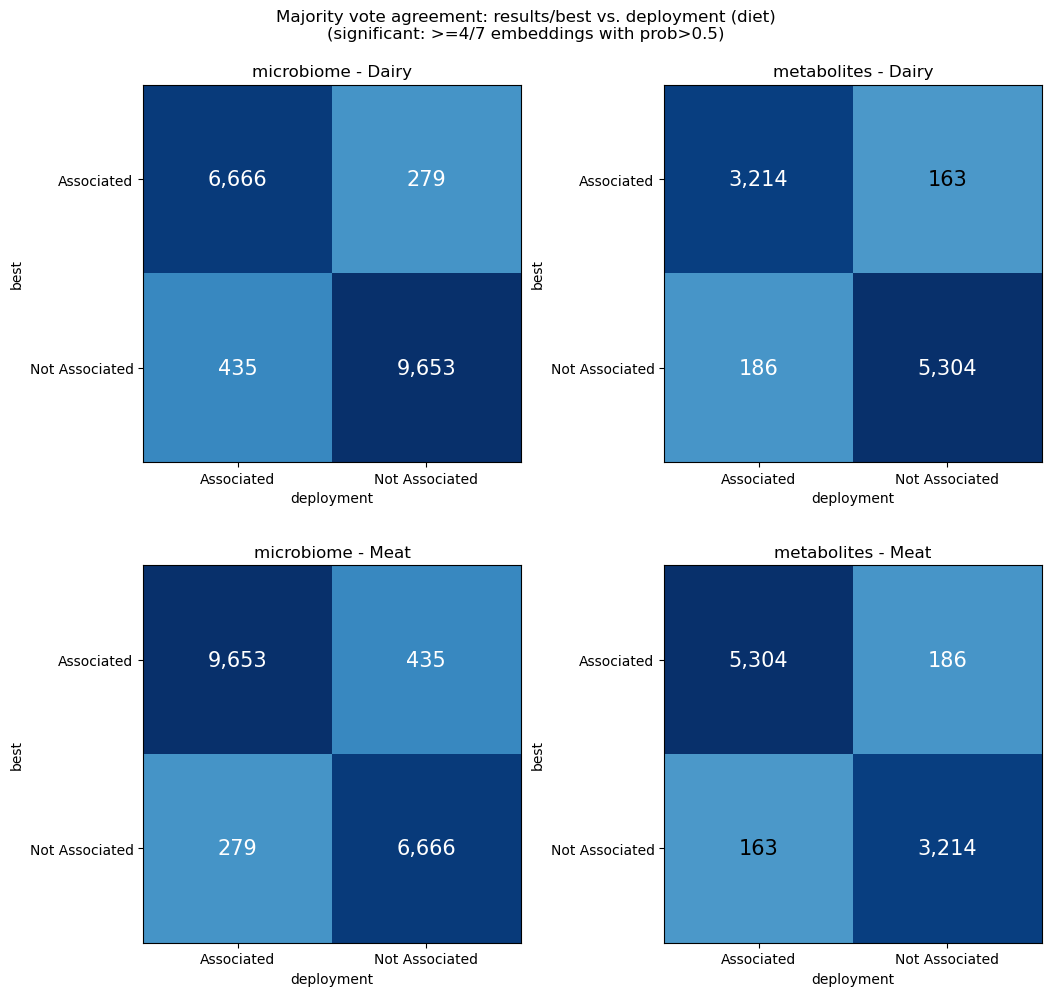

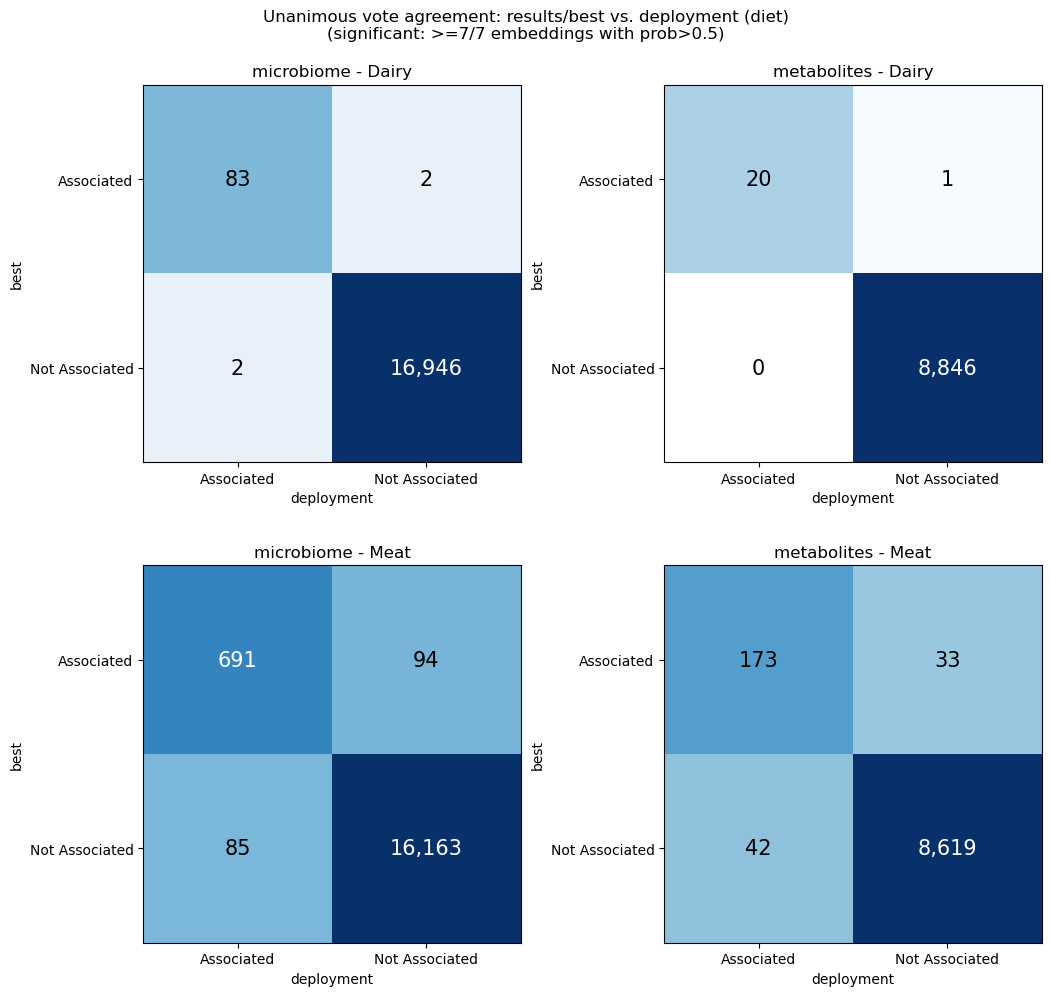

In [9]:
for task in TASKS:
    for vote_name, min_hits in [("Majority vote", 4), ("Unanimous vote", 7)]:
        plot_best_vs_deploy(task, min_hits, vote_name)